In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import calendar
import matplotlib

In [2]:
uber_df = pd.read_csv('My Uber Drives - 2016.csv')
uber_df.head()

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*
0,1/1/2016 21:11,1/1/2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,1/2/2016 1:25,1/2/2016 1:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,1/2/2016 20:25,1/2/2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,1/5/2016 17:31,1/5/2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,1/6/2016 14:42,1/6/2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [3]:
print(uber_df.isnull().sum())
uber_df=uber_df.dropna()

START_DATE*      0
END_DATE*        1
CATEGORY*        1
START*           1
STOP*            1
MILES*           0
PURPOSE*       503
dtype: int64


In [4]:
# Make string as datetime to identify individual components easily
uber_df['START_DATE*'] = pd.to_datetime(uber_df['START_DATE*'], format='%m/%d/%Y %H:%M') 
uber_df['END_DATE*'] = pd.to_datetime(uber_df['END_DATE*'], format='%m/%d/%Y %H:%M')

uber_df['Hour'] = [x.hour for x in uber_df['START_DATE*']]
uber_df['Day'] = [x.day for x in uber_df['START_DATE*']]
uber_df['Month'] = [x.month for x in uber_df['START_DATE*']]
uber_df['weekday'] = [calendar.day_name[x.dayofweek] for x in uber_df['START_DATE*']]
uber_df['Day of week'] = [x.dayofweek for x in uber_df['START_DATE*']]

In [5]:
uber_df.head()

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*,Hour,Day,Month,weekday,Day of week
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,21,1,1,Friday,4
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,20,2,1,Saturday,5
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,17,5,1,Tuesday,1
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,14,6,1,Wednesday,2
5,2016-01-06 17:15:00,2016-01-06 17:19:00,Business,West Palm Beach,West Palm Beach,4.3,Meal/Entertain,17,6,1,Wednesday,2


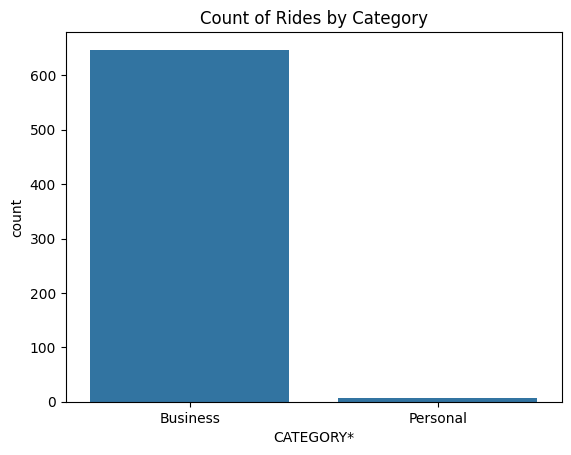

In [6]:
sns.countplot(x='CATEGORY*', data=uber_df)
plt.title('Count of Rides by Category')  # Add a title to the plot
plt.show()  # Display the plot

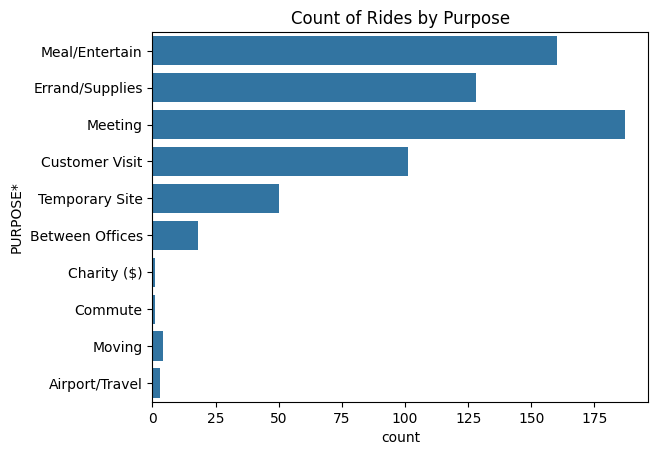

In [7]:
sns.countplot(y='PURPOSE*', data=uber_df)
plt.title('Count of Rides by Purpose')  # Add a title to the plot
plt.show()  # Display the plot

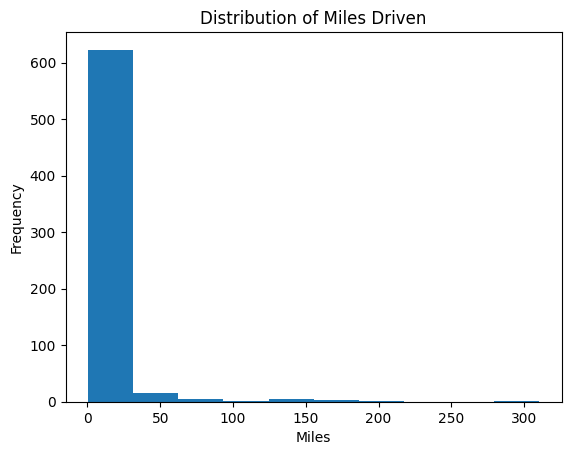

In [8]:
uber_df['MILES*'].plot.hist()
plt.title('Distribution of Miles Driven')  # Add a title
plt.xlabel('Miles')  # Add x-axis label
plt.ylabel('Frequency')  # Add y-axis label
plt.show()  # Display the plot

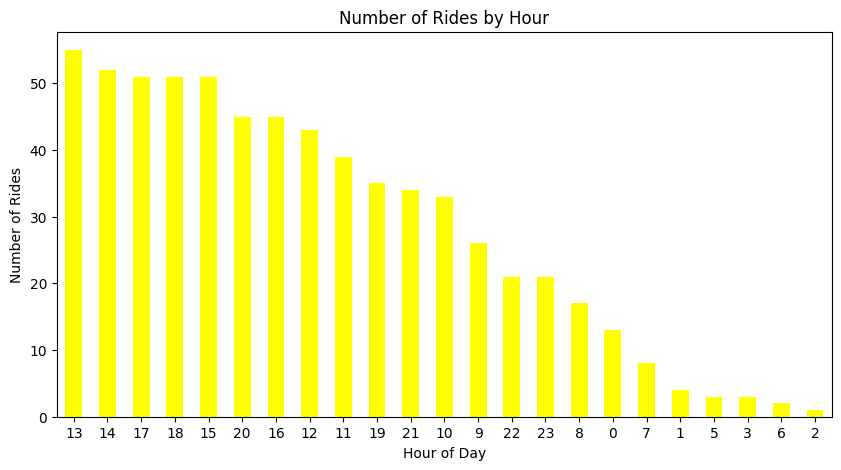

In [9]:
hours = uber_df['Hour'].value_counts()
hours.plot(kind='bar', figsize=(10, 5), color='yellow')
plt.title('Number of Rides by Hour')  # Add a title to the plot
plt.xlabel('Hour of Day')  # Add x-axis label
plt.ylabel('Number of Rides')  # Add y-axis label
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability
plt.show()  # Display the plot

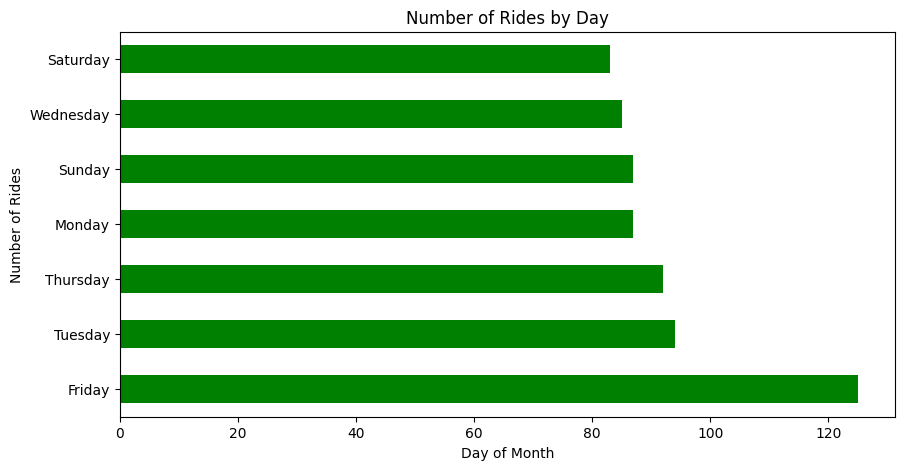

In [10]:
Days = uber_df['weekday'].value_counts()
Days.plot(kind='barh', figsize=(10, 5), color='green')
plt.title('Number of Rides by Day')  # Add a title to the plot
plt.xlabel('Day of Month')  # Add x-axis label
plt.ylabel('Number of Rides')  # Add y-axis label
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability
plt.show()  # Display the plot

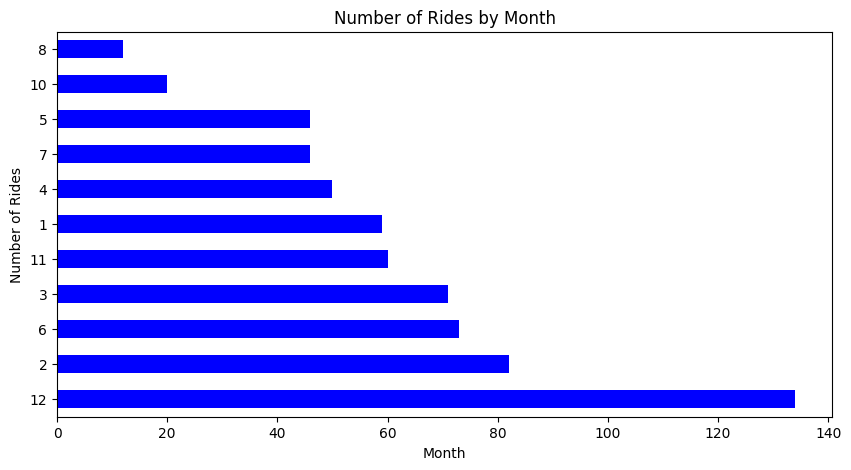

In [11]:
months = uber_df['Month'].value_counts()
months.plot(kind='barh', figsize=(10, 5), color='blue')
plt.title('Number of Rides by Month')  # Add a title to the plot
plt.xlabel('Month')  # Add x-axis label
plt.ylabel('Number of Rides')  # Add y-axis label
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability
plt.show()  # Display the plot

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]),
 [Text(0, 0, '29'),
  Text(1, 0, '21'),
  Text(2, 0, '22'),
  Text(3, 0, '24'),
  Text(4, 0, '20'),
  Text(5, 0, '28'),
  Text(6, 0, '27'),
  Text(7, 0, '19'),
  Text(8, 0, '12'),
  Text(9, 0, '23'),
  Text(10, 0, '31'),
  Text(11, 0, '26'),
  Text(12, 0, '30'),
  Text(13, 0, '1'),
  Text(14, 0, '7'),
  Text(15, 0, '9'),
  Text(16, 0, '2'),
  Text(17, 0, '8'),
  Text(18, 0, '10'),
  Text(19, 0, '25'),
  Text(20, 0, '11'),
  Text(21, 0, '3'),
  Text(22, 0, '14'),
  Text(23, 0, '4'),
  Text(24, 0, '13'),
  Text(25, 0, '18'),
  Text(26, 0, '17'),
  Text(27, 0, '5'),
  Text(28, 0, '15')])

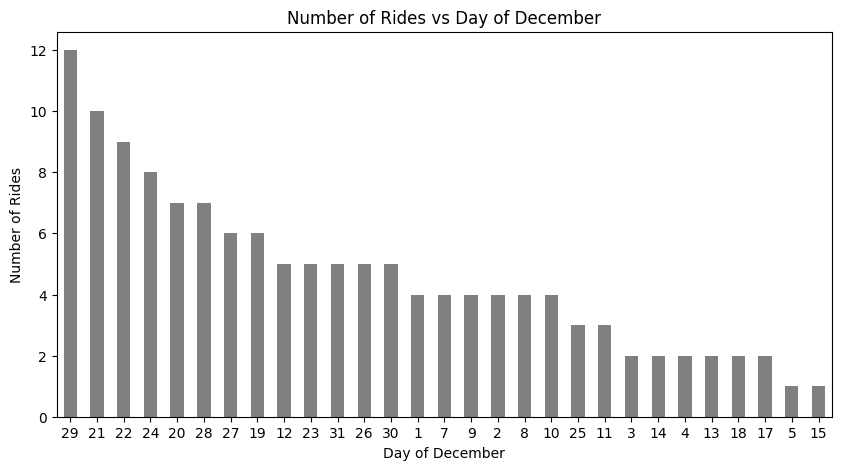

In [12]:
days = uber_df['Day'][uber_df['Month']==12].value_counts()
days.plot(kind='bar', figsize=(10, 5), color='grey')
plt.title('Number of Rides vs Day of December')  # Add a title to the plot
plt.xlabel('Day of December')  # Add x-axis label
plt.ylabel('Number of Rides')  # Add y-axis label
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability

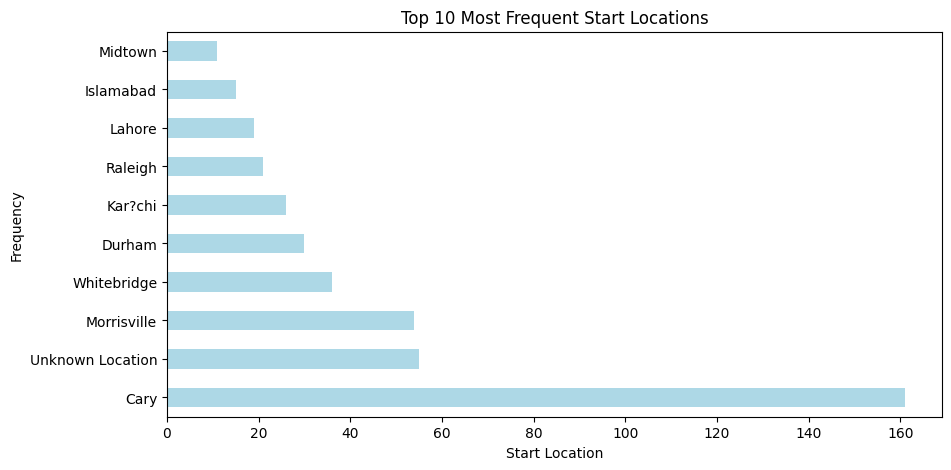

In [13]:
months = uber_df['START*'].value_counts().nlargest(10)
months.plot(kind='barh', figsize=(10, 5), color='lightblue')
plt.title('Top 10 Most Frequent Start Locations')  # Add a title to the plot
plt.xlabel('Start Location')  # Add x-axis label
plt.ylabel('Frequency')  # Add y-axis label
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability
plt.show()  # Display the plot

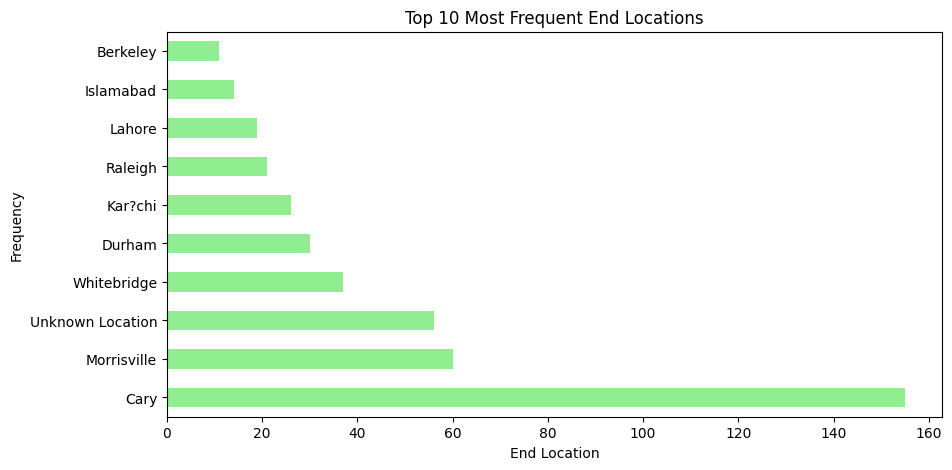

In [14]:
months = uber_df['STOP*'].value_counts().nlargest(10)
months.plot(kind='barh', figsize=(10, 5), color='lightgreen')
plt.title('Top 10 Most Frequent End Locations')  # Add a title to the plot
plt.xlabel('End Location')  # Add x-axis label
plt.ylabel('Frequency')  # Add y-axis label
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability
plt.show()  # Display the plot

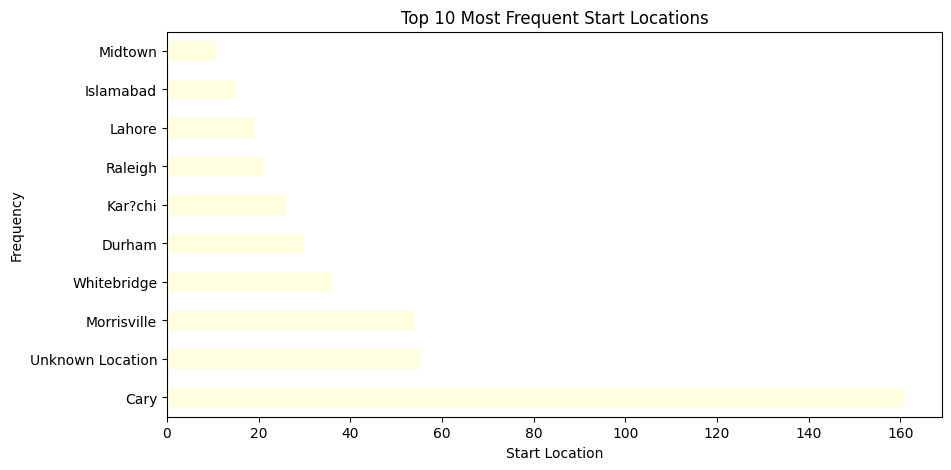

In [15]:
# Filter rows where 'STOP*' is not null and count the most frequent 'START*' locations
filtered_df = uber_df[uber_df[['START*', 'STOP*']].notnull().all(axis=1)]
months = filtered_df['START*'].value_counts().nlargest(10)
months.plot(kind='barh', figsize=(10, 5), color='lightyellow')
plt.title('Top 10 Most Frequent Start Locations')  # Add a title to the plot
plt.xlabel('Start Location')  # Add x-axis label    
plt.ylabel('Frequency')  # Add y-axis label
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability
plt.show()  # Display the plot

In [16]:
df2= pd.read_csv('rideshare_kaggle.csv')
df2.head()

,id,timestamp,hour,day,month,datetime,timezone,source,destination,cab_type,...,precipIntensityMax,uvIndexTime,temperatureMin,temperatureMinTime,temperatureMax,temperatureMaxTime,apparentTemperatureMin,apparentTemperatureMinTime,apparentTemperatureMax,apparentTemperatureMaxTime
0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,1.544953e+09,9,16,12,2018-12-16 09:30:07,America/New_York,Haymarket Square,North Station,Lyft,...,0.1276,1544979600,39.89,1545012000,43.68,1544968800,33.73,1545012000,38.07,1544958000
1,4bd23055-6827-41c6-b23b-3c491f24e74d,1.543284e+09,2,27,11,2018-11-27 02:00:23,America/New_York,Haymarket Square,North Station,Lyft,...,0.1300,1543251600,40.49,1543233600,47.30,1543251600,36.20,1543291200,43.92,1543251600
2,981a3613-77af-4620-a42a-0c0866077d1e,1.543367e+09,1,28,11,2018-11-28 01:00:22,America/New_York,Haymarket Square,North Station,Lyft,...,0.1064,1543338000,35.36,1543377600,47.55,1543320000,31.04,1543377600,44.12,1543320000
3,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,1.543554e+09,4,30,11,2018-11-30 04:53:02,America/New_York,Haymarket Square,North Station,Lyft,...,0.0000,1543507200,34.67,1543550400,45.03,1543510800,30.30,1543550400,38.53,1543510800
4,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,1.543463e+09,3,29,11,2018-11-29 03:49:20,America/New_York,Haymarket Square,North Station,Lyft,...,0.0001,1543420800,33.10,1543402800,42.18,1543420800,29.11,1543392000,35.75,1543420800


In [17]:
extra_cols = [
	'apparentTemperature', 'precipIntensity', 'humidity', 'windSpeed', 'windGust', 'apparentTemperatureHigh', 
	'dewPoint', 'precipIntensityMax', 'apparentTemperatureMax', 'cloudCover', 'moonPhase', 'windGustTime', 
	'visibility', 'temperatureHighTime', 'temperatureLowTime', 'apparentTemperatureHighTime', 
	'apparentTemperatureLow', 'apparentTemperatureLowTime', 'temperatureMinTime', 'temperatureMaxTime', 
	'apparentTemperatureMin', 'apparentTemperatureMinTime', 'apparentTemperatureMaxTime', 'windBearing', 
	'uvIndex', 'visibility.1', 'ozone', 'sunriseTime', 'sunsetTime', 'uvIndexTime'
]

df2= df2.drop(extra_cols, axis=1)

In [18]:
df2.head()

,id,timestamp,hour,day,month,datetime,timezone,source,destination,cab_type,...,temperature,short_summary,long_summary,precipProbability,temperatureHigh,temperatureLow,icon,pressure,temperatureMin,temperatureMax
0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,1.544953e+09,9,16,12,2018-12-16 09:30:07,America/New_York,Haymarket Square,North Station,Lyft,...,42.34,Mostly Cloudy,Rain throughout the day.,0.0,43.68,34.19,partly-cloudy-night,1021.98,39.89,43.68
1,4bd23055-6827-41c6-b23b-3c491f24e74d,1.543284e+09,2,27,11,2018-11-27 02:00:23,America/New_York,Haymarket Square,North Station,Lyft,...,43.58,Rain,"Rain until morning, starting again in the eve...",1.0,47.30,42.10,rain,1003.97,40.49,47.30
2,981a3613-77af-4620-a42a-0c0866077d1e,1.543367e+09,1,28,11,2018-11-28 01:00:22,America/New_York,Haymarket Square,North Station,Lyft,...,38.33,Clear,Light rain in the morning.,0.0,47.55,33.10,clear-night,992.28,35.36,47.55
3,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,1.543554e+09,4,30,11,2018-11-30 04:53:02,America/New_York,Haymarket Square,North Station,Lyft,...,34.38,Clear,Partly cloudy throughout the day.,0.0,45.03,28.90,clear-night,1013.73,34.67,45.03
4,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,1.543463e+09,3,29,11,2018-11-29 03:49:20,America/New_York,Haymarket Square,North Station,Lyft,...,37.44,Partly Cloudy,Mostly cloudy throughout the day.,0.0,42.18,36.71,partly-cloudy-night,998.36,33.10,42.18


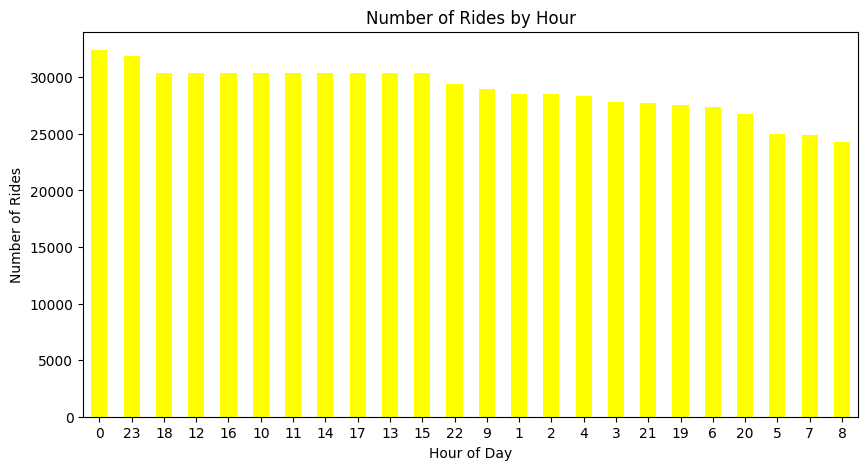

In [19]:
hours = df2['hour'].value_counts()
hours.plot(kind='bar', figsize=(10, 5), color='yellow')
plt.title('Number of Rides by Hour')  # Add a title to the plot
plt.xlabel('Hour of Day')  # Add x-axis label
plt.ylabel('Number of Rides')  # Add y-axis label
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability
plt.show()  # Display the plot

In [20]:
day_week = [calendar.day_name[x.dayofweek] for x in pd.to_datetime(df2['datetime'], format='%Y-%m-%d %H:%M:%S')]
day_week = pd.Series(day_week)

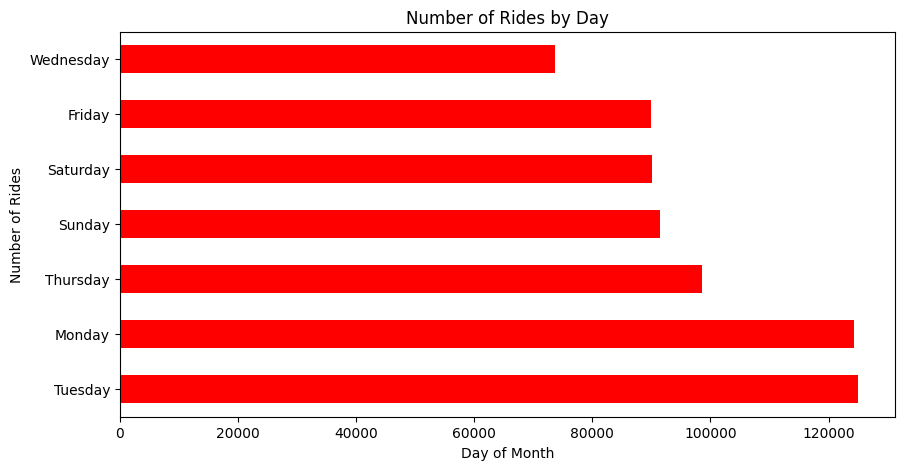

In [21]:
days = day_week.value_counts()
days.plot(kind='barh', figsize=(10, 5), color='red')  # Use a valid color name
plt.title('Number of Rides by Day')  # Add a title to the plot
plt.xlabel('Day of Month')  # Add x-axis label
plt.ylabel('Number of Rides')  # Add y-axis label
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability
plt.show()  # Display the plot

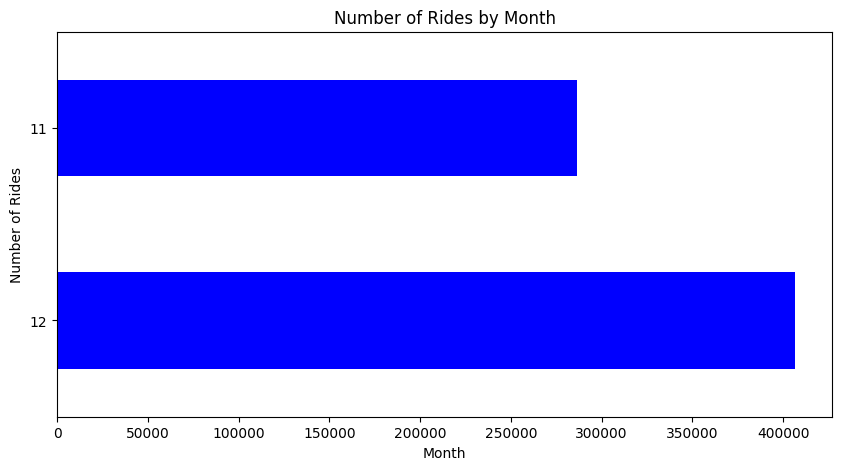

In [22]:
months = df2[df2['month'].isin([11, 12])]['month'].value_counts()
months.plot(kind='barh', figsize=(10, 5), color='blue')
plt.title('Number of Rides by Month')  # Add a title to the plot
plt.xlabel('Month')  # Add x-axis label
plt.ylabel('Number of Rides')  # Add y-axis label
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability
plt.show()  # Display the plot


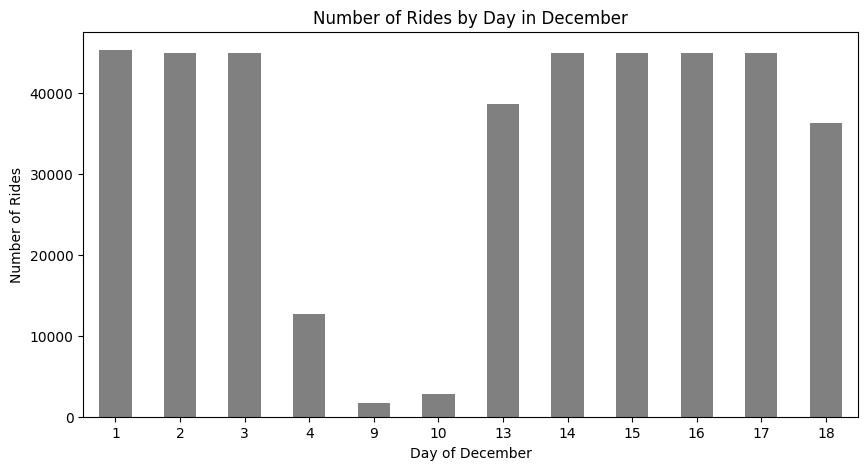

In [23]:
# Filter data for December
december_data = df2[df2['month'] == 12]

# Count the number of rides for each day in December
days = december_data['day'].value_counts().sort_index()

# Plot the data
days.plot(kind='bar', figsize=(10, 5), color='grey')
plt.title('Number of Rides by Day in December')  # Add a title to the plot
plt.xlabel('Day of December')  # Add x-axis label
plt.ylabel('Number of Rides')  # Add y-axis label
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability
plt.show()  # Display the plot

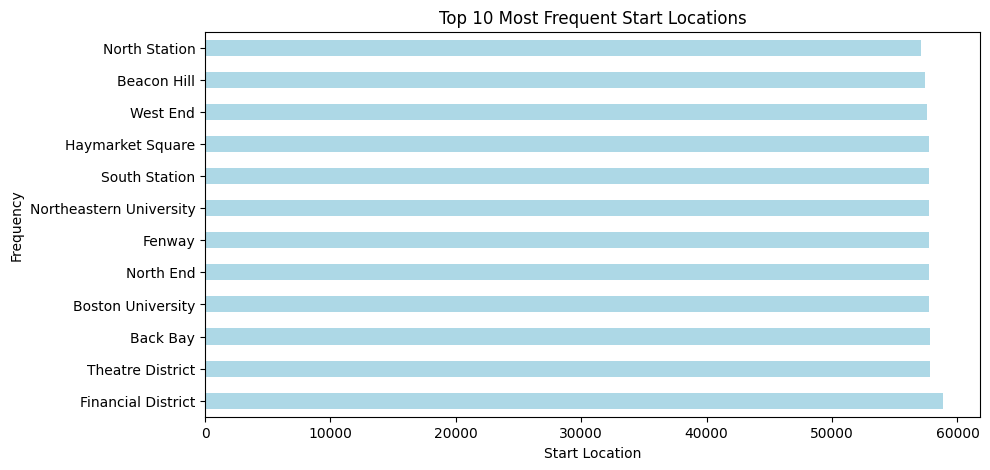

In [24]:
source = df2['source'].value_counts()
source.plot(kind='barh', figsize=(10, 5), color='lightblue')
plt.title('Top 10 Most Frequent Start Locations')  # Add a title to the plot
plt.xlabel('Start Location')  # Add x-axis label
plt.ylabel('Frequency')  # Add y-axis label
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability
plt.show()  # Display the plot

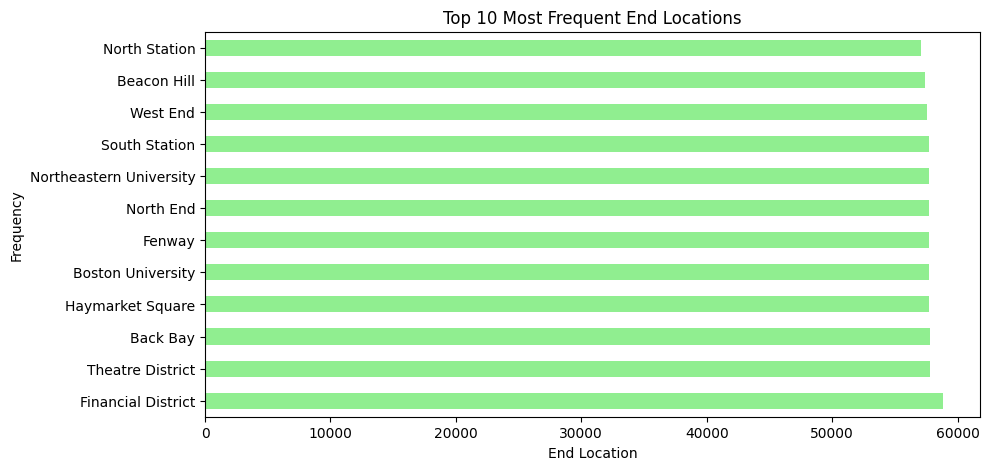

In [25]:
destination = df2['destination'].value_counts()
destination.plot(kind='barh', figsize=(10, 5), color='lightgreen')
plt.title('Top 10 Most Frequent End Locations')  # Add a title to the plot
plt.xlabel('End Location')  # Add x-axis label
plt.ylabel('Frequency')  # Add y-axis label
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability
plt.show()  # Display the plot

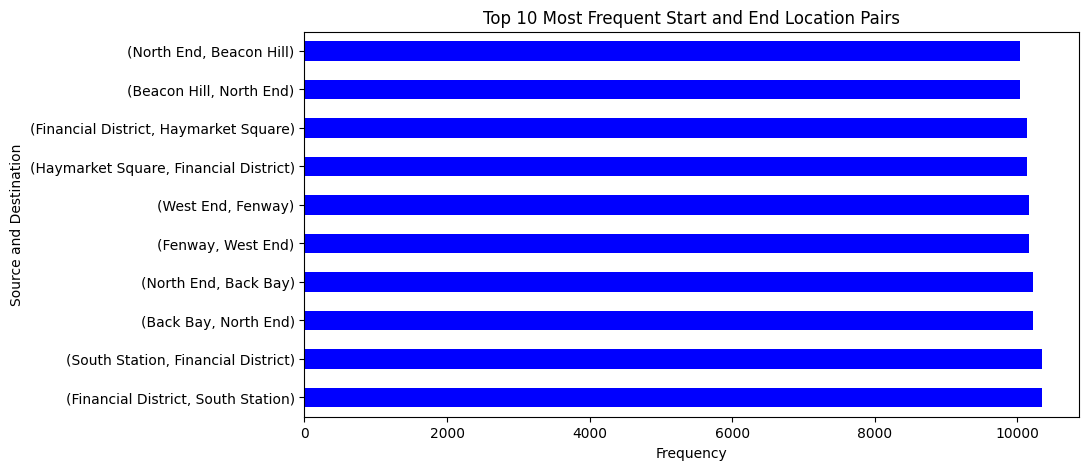

In [26]:
Trip = df2.groupby(['source', 'destination']).size().nlargest(10)# Count the most frequent start and end location pairs using groupby and size
Trip.plot(kind='barh', figsize=(10, 5), color='blue')  # Use a valid color name
plt.title('Top 10 Most Frequent Start and End Location Pairs')  # Add a title to the plot
plt.xlabel('Frequency')  # Add x-axis label
plt.ylabel('Source and Destination')  # Add y-axis label
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability
plt.show()  # Display the plot

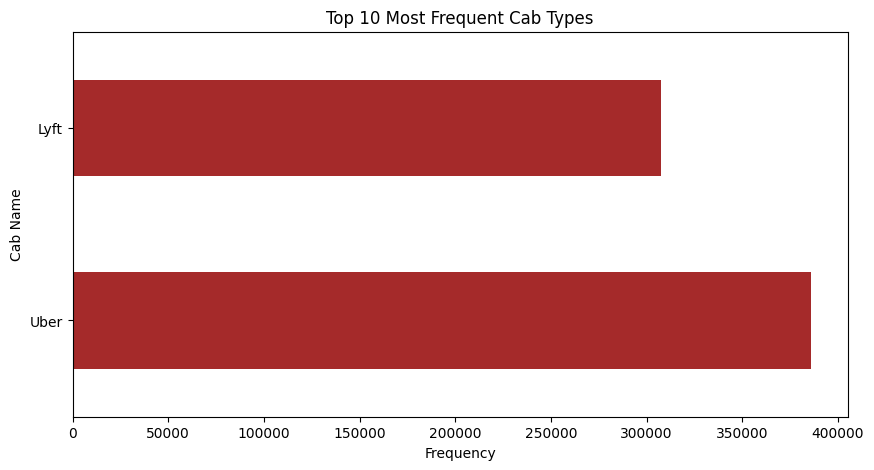

In [27]:
Cab_Type = df2['cab_type'].value_counts()
Cab_Type.plot(kind='barh', figsize=(10, 5), color='brown')  # Use a valid color name
plt.title('Top 10 Most Frequent Cab Types')  # Add a title to the plot
plt.xlabel('Frequency')  # Add x-axis label
plt.ylabel('Cab Name')  # Add y-axis label
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability
plt.show()  # Display the plot

In [28]:
from sklearn import preprocessing
lable_encoder = preprocessing.LabelEncoder()

In [29]:
df2["id"] = lable_encoder.fit_transform(df2["id"])
df2['timezone'] = lable_encoder.fit_transform(df2['timezone'])
df2['datetime'] = lable_encoder.fit_transform(df2['datetime'])
df2['destination'] = lable_encoder.fit_transform(df2['destination'])
df2['product_id'] = lable_encoder.fit_transform(df2['product_id'])
df2['short_summary'] = lable_encoder.fit_transform(df2['short_summary'])
df2['long_summary'] = lable_encoder.fit_transform(df2['long_summary'])
df2['name'] = lable_encoder.fit_transform(df2['name'])

In [30]:
print("Class mapping of Name ")
for i, item in enumerate(lable_encoder.classes_):
    print(item, " : ", i)

Class mapping of Name 
Black  :  0
Black SUV  :  1
Lux  :  2
Lux Black  :  3
Lux Black XL  :  4
Lyft  :  5
Lyft XL  :  6
Shared  :  7
Taxi  :  8
UberPool  :  9
UberX  :  10
UberXL  :  11
WAV  :  12


In [31]:
df2['source'] = lable_encoder.fit_transform(df2['source'])

print("Class mapping of Name ")
for i, item in enumerate(lable_encoder.classes_):
    print(item, " : ", i)

Class mapping of Name 
Back Bay  :  0
Beacon Hill  :  1
Boston University  :  2
Fenway  :  3
Financial District  :  4
Haymarket Square  :  5
North End  :  6
North Station  :  7
Northeastern University  :  8
South Station  :  9
Theatre District  :  10
West End  :  11


In [32]:
df2['icon'] = lable_encoder.fit_transform(df2['icon'])
print("Class mapping of Name ")
for i, item in enumerate(lable_encoder.classes_):
    print(item, " : ", i)

Class mapping of Name 
 clear-day   :  0
 clear-night   :  1
 cloudy   :  2
 fog   :  3
 partly-cloudy-day   :  4
 partly-cloudy-night   :  5
 rain   :  6


In [33]:
df2['cab_type'] = lable_encoder.fit_transform(df2['cab_type'])  
print("Class mapping of Name ")
for i, item in enumerate(lable_encoder.classes_):
    print(item, " : ", i)

Class mapping of Name 
Lyft  :  0
Uber  :  1


In [34]:
len(df2[df2['cab_type'] == 1]) 

385663

In [35]:
X= df2[df2['cab_type'] == 1].drop(['cab_type'], axis=1)
y= df2[df2['cab_type'] == 1]['price']

In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer

# Remove rows where y_train is NaN
mask = ~pd.isnull(y_train)
X_train = X_train[mask]
y_train = y_train[mask]

# Also fix X_test if necessary
mask_test = ~pd.isnull(y_test)
X_test = X_test[mask_test]
y_test = y_test[mask_test]


In [38]:

print("NaNs in X_train:", np.isnan(X_train).sum())
print("NaNs in X_test:", np.isnan(X_test).sum())
print("NaNs in y_train:", np.isnan(y_train).sum())


NaNs in X_train: id                   0
timestamp            0
hour                 0
day                  0
month                0
datetime             0
timezone             0
source               0
destination          0
product_id           0
name                 0
price                0
distance             0
surge_multiplier     0
latitude             0
longitude            0
temperature          0
short_summary        0
long_summary         0
precipProbability    0
temperatureHigh      0
temperatureLow       0
icon                 0
pressure             0
temperatureMin       0
temperatureMax       0
dtype: int64
NaNs in X_test: id                   0
timestamp            0
hour                 0
day                  0
month                0
datetime             0
timezone             0
source               0
destination          0
product_id           0
name                 0
price                0
distance             0
surge_multiplier     0
latitude             0
longitude  

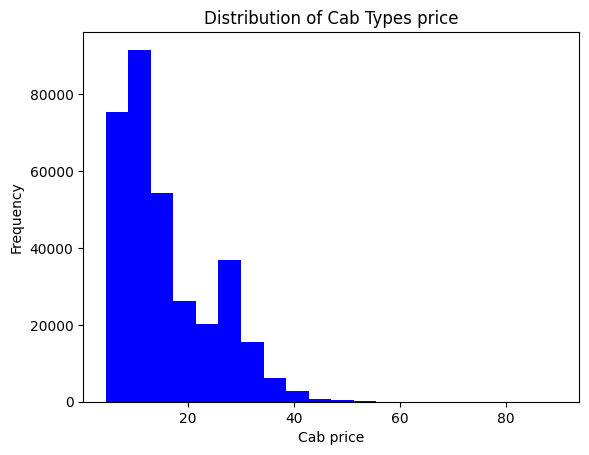

In [39]:
plt.hist(y, bins=20, color='blue')
plt.title('Distribution of Cab Types price')  # Add a title to the plot
plt.xlabel('Cab price')  # Add x-axis label
plt.ylabel('Frequency')  # Add y-axis label
plt.show()  # Display the plot

In [40]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn import ensemble

In [44]:

def train_test_model(X_train, y_train, X_test, y_test):
    print('Linear Regression...')
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    print(lr_model.score(X_test, y_test))

    print('Decision Tree...')
    dt_model = DecisionTreeRegressor(random_state=0, max_depth=10)
    dt_model= dt_model.fit(X_train, y_train)
    print(dt_model.score(X_test, y_test))

    print('Random Forest...')
    rf_model = RandomForestRegressor(random_state=0, n_estimators=20)
    rf_model= rf_model.fit(X_train, y_train)
    print(rf_model.score(X_test, y_test))

    print('GBM...')
    gbm = ensemble.GradientBoostingRegressor(n_estimators=200, max_depth=5)
    gbm= gbm.fit(X_train, y_train)
    print(gbm.score(X_test, y_test))

    return [lr_model, dt_model, rf_model, gbm]


In [47]:
# Train and test the models
def feature_elimination(train_test_model, X, y, n_features=40):
    # Combine X and y into a DataFrame and drop rows with NaN in either
    data = pd.concat([X, y], axis=1)
    data.dropna(inplace=True)

    X_clean = data.iloc[:, :-1]
    y_clean = data.iloc[:, -1]

    # Perform feature elimination
    rfe = RFE(train_test_model, n_features_to_select=n_features)
    rfe = rfe.fit(X_clean, y_clean)

    # Select important features
    X_new = X_clean[X_clean.columns[rfe.support_]]

    # Split again after feature selection
    X_train, X_test, y_train, y_test = train_test_split(X_new, y_clean, test_size=0.2, random_state=0)

    # Optionally print or return results
    print("Selected features:", list(X_new.columns))
    return X_train, X_test, y_train, y_test


In [48]:
model_list = train_test_model(X_train, y_train, X_test, y_test)
n_features = [5,10,15,20]

for model in model_list:
    for nf in n_features:
        print(f"{model} --> {nf} features")
        feature_elimination(model, X, y, nf)

Linear Regression...
1.0
Decision Tree...
0.9999993066667929
Random Forest...
0.9999976442881515
GBM...
0.9999996894551102
LinearRegression() --> 5 features
Selected features: ['source', 'destination', 'name', 'price', 'latitude']
LinearRegression() --> 10 features
Selected features: ['source', 'destination', 'name', 'price', 'distance', 'latitude', 'temperature', 'precipProbability', 'temperatureMin', 'temperatureMax']
LinearRegression() --> 15 features
Selected features: ['hour', 'day', 'source', 'destination', 'name', 'price', 'distance', 'latitude', 'longitude', 'temperature', 'long_summary', 'precipProbability', 'icon', 'temperatureMin', 'temperatureMax']
LinearRegression() --> 20 features
Selected features: ['hour', 'day', 'month', 'source', 'destination', 'name', 'price', 'distance', 'surge_multiplier', 'latitude', 'longitude', 'temperature', 'short_summary', 'long_summary', 'precipProbability', 'temperatureHigh', 'icon', 'pressure', 'temperatureMin', 'temperatureMax']
DecisionT